### Этап 1. Подготовка данных
Скачайте файл с набором данных событий информационной безопасности 
в формате JSON (events.json). Важно: можно сгенерировать данные
самостоятельно или использовать предоставленные.
### Этап 2. Анализ данных
Загрузите данные из файла JSON в датафрейм с помощью Pandas
и проанализируйте их. Вы должны изучить распределение событий
информационной безопасности по их типам (по полю «signature»).
### Этап 3. Визуализация данных
Постройте график распределения типов событий информационной
безопасности. Используйте Seaborn или Matplotlib для создания
визуализации.


=== Первые строки данных ===
            timestamp                                          signature
0 2023-08-21 08:00:00  MALWARE-CNC Win.Trojan.Jadtre variant outbound...
1 2023-08-21 09:00:00  EXPLOIT Remote Windows Win32k elevation of pri...
2 2023-08-21 10:00:00            EXPLOIT Java JRE to Oracle WebLogic RCE
3 2023-08-21 11:00:00          NETBIOS DCERPC NCACN-IP-TCP interfaces BO
4 2023-08-21 12:00:00  MALWARE-CNC User-Agent known malicious connect... 

=== Распределение по signature ===
                                                   signature  count  share
   MALWARE-CNC Win.Trojan.Jadtre variant outbound connection     12   0.12
EXPLOIT Remote Windows Win32k elevation of privilege attempt     11   0.11
                     EXPLOIT Java JRE to Oracle WebLogic RCE     11   0.11
                   NETBIOS DCERPC NCACN-IP-TCP interfaces BO     11   0.11
        MALWARE-CNC User-Agent known malicious connecting IP     11   0.11
  INDICATOR-COMPROMISE Suspicious inbound to m

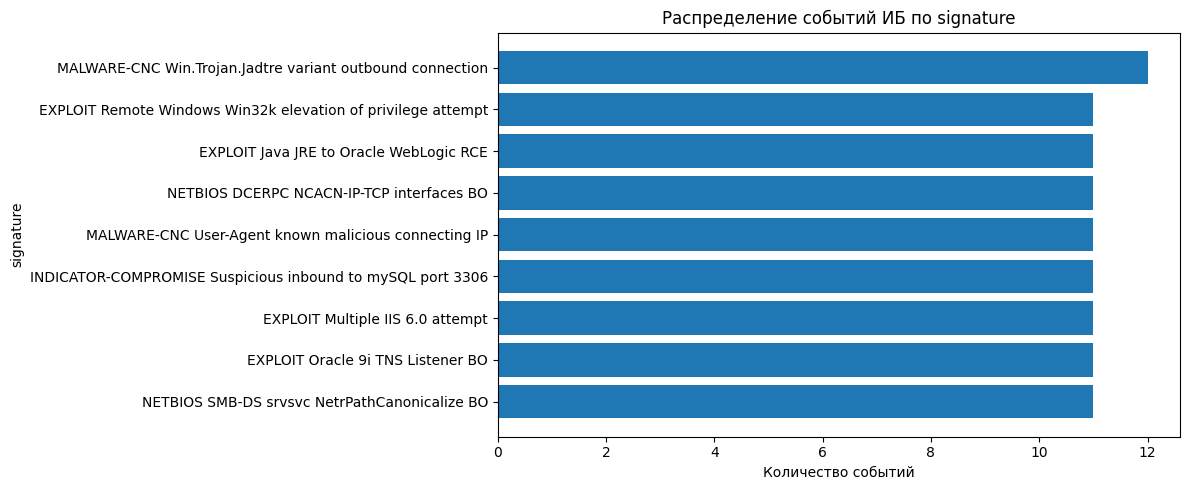

In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("events.json") 
TOP_N = 20

def load_events_json(path: Path) -> pd.DataFrame:

    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict) and "events" in data and isinstance(data["events"], list):
        events = data["events"]
    elif isinstance(data, list):
        events = data
    else:
        raise ValueError("Неожиданный формат JSON. Ожидалось {'events': [...]} или просто [...]")

    df = pd.DataFrame(events)

    if "signature" not in df.columns:
        raise ValueError("В данных нет поля 'signature'.")

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    return df


def signature_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """
    Возвращает таблицу распределения по signature: signature, count, share
    """
    counts = df["signature"].value_counts(dropna=False).rename_axis("signature").reset_index(name="count")
    total = counts["count"].sum()
    counts["share"] = (counts["count"] / total).round(4)
    return counts


def plot_distribution(dist: pd.DataFrame, top_n: int = TOP_N) -> None:
    """
    Горизонтальная диаграмма (удобнее для длинных signature).
    Если signature слишком много — показываем топ-N, остальные в Other.
    """
    dist = dist.copy()

    if len(dist) > top_n:
        top = dist.head(top_n)
        other_count = dist.iloc[top_n:]["count"].sum()
        other_share = dist.iloc[top_n:]["share"].sum()

        dist_plot = pd.concat(
            [
                top,
                pd.DataFrame([{"signature": "Other", "count": other_count, "share": round(other_share, 4)}]),
            ],
            ignore_index=True,
        )
    else:
        dist_plot = dist

    plt.figure(figsize=(12, max(5, 0.5 * len(dist_plot))))
    plt.barh(dist_plot["signature"], dist_plot["count"])
    plt.gca().invert_yaxis()  # чтобы самый частый был сверху
    plt.title("Распределение событий ИБ по signature")
    plt.xlabel("Количество событий")
    plt.ylabel("signature")
    plt.tight_layout()
    plt.show()


def main():
    df = load_events_json(DATA_PATH)

    print("=== Первые строки данных ===")
    print(df.head(), "\n")

    dist = signature_distribution(df)

    print("=== Распределение по signature ===")
    print(dist.to_string(index=False), "\n")

    plot_distribution(dist, top_n=TOP_N)


if __name__ == "__main__":
    main()
